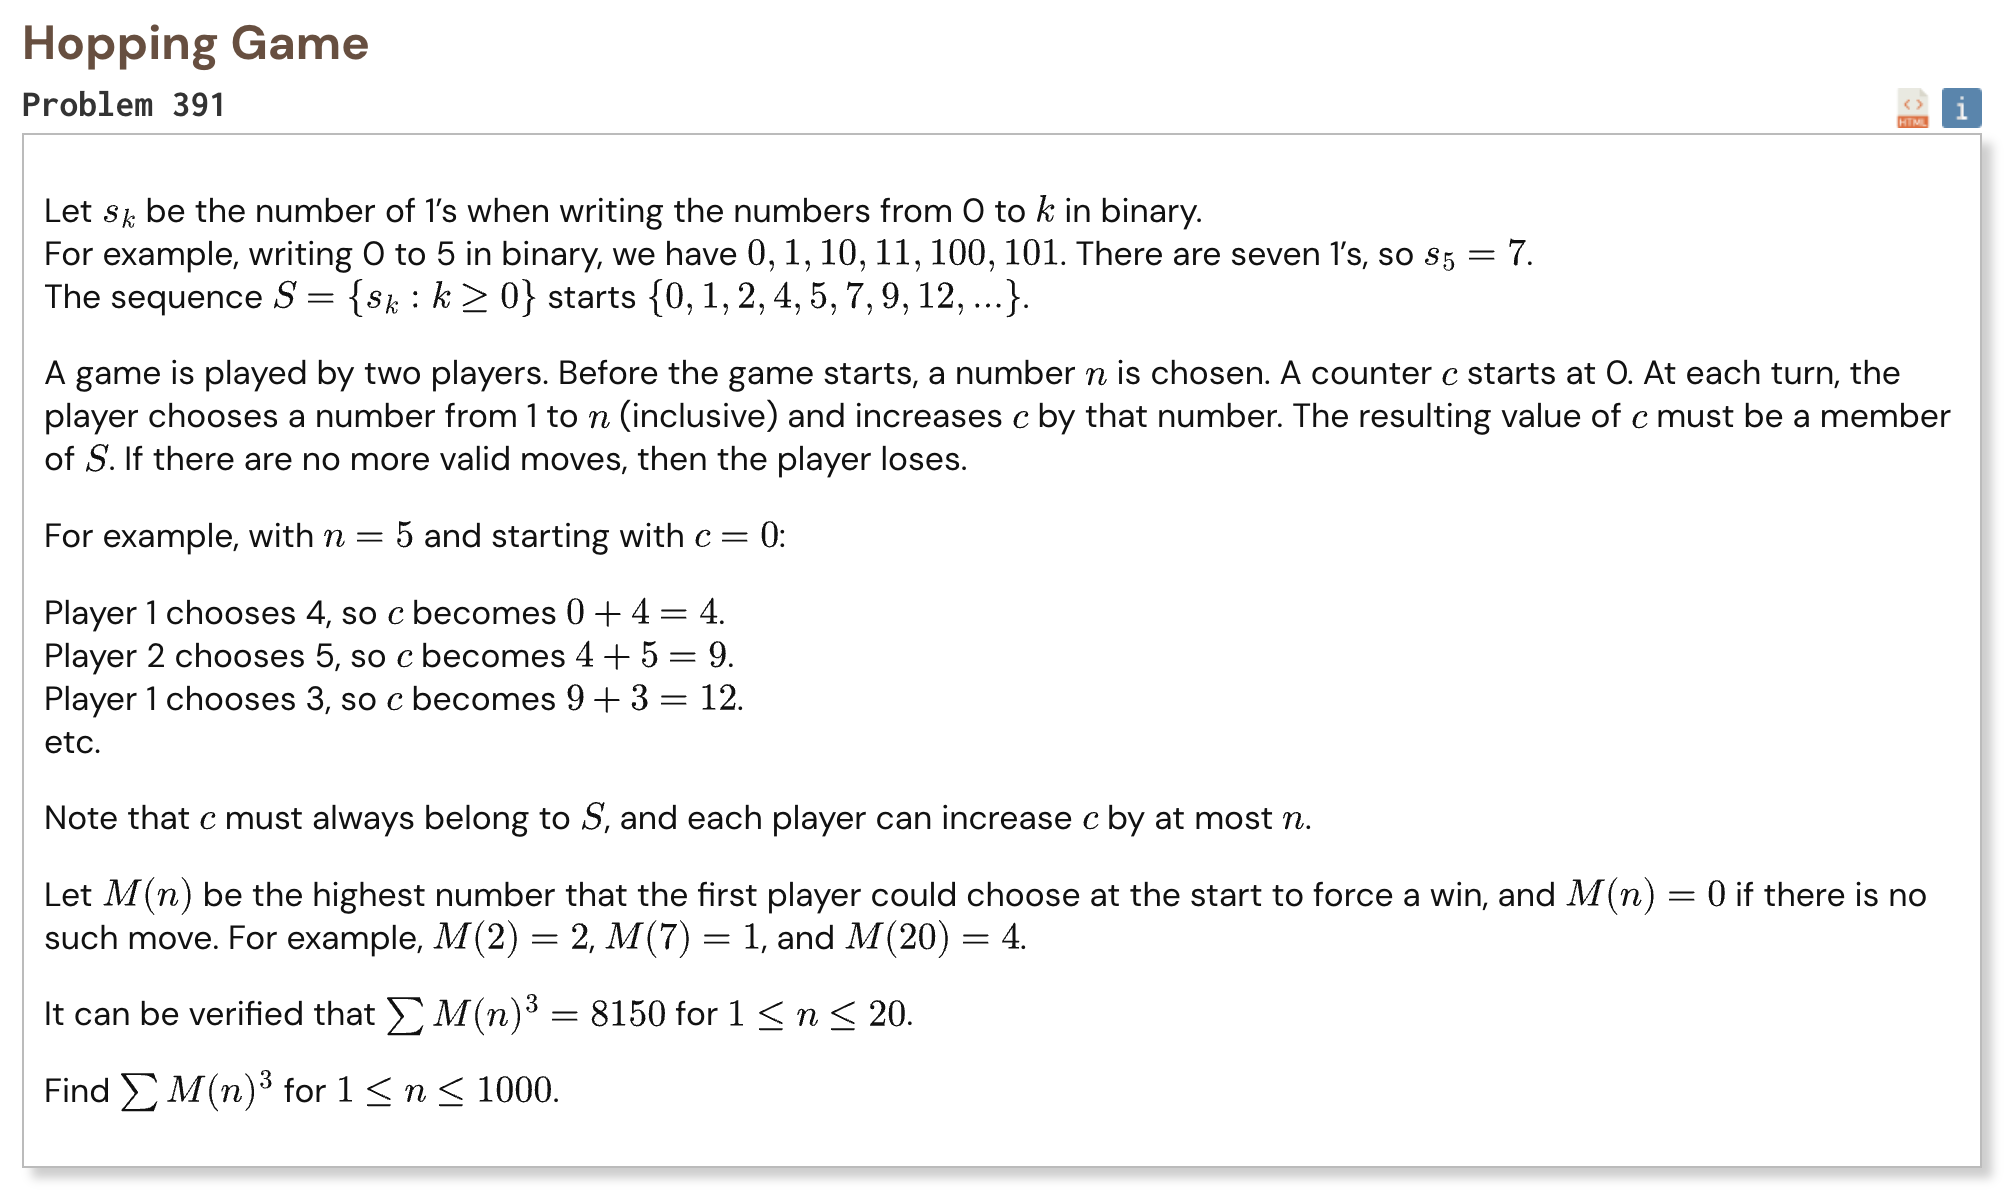

## Initial approach

* consecutive values in the sequence differ by the number of 1 bits in the next integer
* work backwards through these differences to determine whether a position is winning or losing
* keep a value between 0 and n and reset it to 0 whenever the next difference would exceed n
* the final value after the backward scan gives the largest winning first move M n
* popcount values below a power of two have a recursive two half structure
* represent each whole recursive block as a small transformation table instead of generating a huge sequence
* compose these tables until the transformation becomes constant
* calculate M n for every n from 1 to 1000 and add their cubes 

In [1]:
def constant_value(table):
    first = table[0]

    for value in table[1:]:
        if value != first:
            return None

    return first


def apply_map(mapping, value):
    if mapping is None:
        return value

    if isinstance(mapping, int):
        return mapping

    return mapping[value]


def compose(first, second):
    if isinstance(first, int):
        return first

    if isinstance(second, int):
        return apply_map(first, second)

    if first is None:
        return second

    if second is None:
        return first

    return [first[value] for value in second]


def max_winning_move(n):
    max_level = 40
    width = max_level + 2

    previous = [0] * width
    previous[0] = None

    for offset in range(1, width):
        if offset > n:
            previous[offset] = 0
        else:
            limit = n - offset
            table = [0] * (n + 1)

            for state in range(limit + 1):
                table[state] = state + offset

            previous[offset] = table

    for _ in range(max_level):
        current = [0] * width

        for offset in range(width - 1):
            current[offset] = compose(
                previous[offset],
                previous[offset + 1]
            )

        root = current[0]

        if root is not None and not isinstance(root, int):
            value = constant_value(root)

            if value is not None:
                root = value

        if isinstance(root, int):
            return root

        previous = current

    raise RuntimeError("maximum level is too small")

In [2]:
%%time
assert max_winning_move(2) == 2
assert max_winning_move(7) == 1
assert max_winning_move(20) == 4
assert sum(max_winning_move(n) ** 3 for n in range(1, 21)) == 8150

result = sum(
    max_winning_move(n) ** 3
    for n in range(1, 1001)
)

print("Result:", result)

Result: 61029882288
CPU times: user 8.05 s, sys: 110 ms, total: 8.16 s
Wall time: 8.37 s
